# init
---

In [1]:
#### mv packages ####
import modules.data as d
import modules.model as m
import modules.pooling as p
import modules.train as t
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device, generator = u.Devices().auto_set_device()#['cuda:1', 'cuda:0'])
# device, generator = u.Devices().set_device('cpu')

#### data ####
brca = d.Preprocessor(
    tcga_project='TCGA-BRCA',
    tcga_dir=dataset_dir/'tcga',
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv',
    metadata_subtype_col = 'paper_BRCA_Subtype_PAM50',
    
    # counts
    apply_DESeq_norm=False, 
    log_transform=False,
    scale_method=None,

    # etc
    y_col = 'subtype',
    drop = {'subtype':['Normal', 'Primary Tumor']},
    max_subset = 120,
)
_dataset = d.GraphDataset(brca)
_batch = d.get_toy_databatch(_dataset, generator)

# #### Device() ####
# device = cuda:4

# #### Preprocessor() ####
# log0_method              log1p                    str
# class_weights            (6,)                     Tensor (cuda:4)
# edge_index               (2, 32798)               Tensor (cuda:4)
# edge_attr                (32798, 16)              Tensor (cuda:4)
# gene_counts              (4383, 562)              DataFrame
# metadata                 (562, 3)                 DataFrame
# relation                 (32798, 18)              DataFrame
# node_id_map              4383                     dict
# mask_list                305                      list
# mask                     (4383, 305)              Tensor (cuda:4)
# x                        (562, 4383, 1)           Tensor (cuda:4)
# y                        (562,)                   Tensor (cuda:4)
# y_labels                 6                        list
# num_samples              562                      int
# num_nodes                4383                     int


In [2]:
#### convenience variables ####
_embedding_size = 16

# from mask (init)
_mask = brca.mask
_num_nodes, _num_sets = _mask.shape

# from batch (forward)
_batch_size = int(_batch.x.shape[0]/_num_nodes)
_num_node_features = _batch.x.shape[1] # or brca.num_node_features
_x = _batch.x.view(_batch.batch_size, int(_batch.x.shape[0]/_batch.batch_size), -1)

# temp utils
---

In [3]:
## packages

from modules.utils import reshape, filter_kwargs
from modules.model import cloneable, get_layers, attn_dims

import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.nn import MessagePassing, GCNConv, GATConv

from torch import Tensor
from torch_geometric.data import Batch, Data # Batch is a subclass of Data
from typing import Literal, Optional, Union

##

from modules.train import Loader, Trainer, NBLoss
from torchmetrics.functional import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

##

import numpy as np
import scipy.cluster.hierarchy as sch

import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
def input_to_dict(input):
    if isinstance(input, Tensor): # x (Tensor) only
        data = {'x':input}
    elif isinstance(input, Data): # PyG Data or DataBatch
        data = {key: getattr(input, key) for key in input.keys()}
    elif isinstance(input, dict): # predefined dict
        data = input
    else:
        raise TypeError(f'unsupported input type: {type(input)}')
    return data

In [5]:
@cloneable # Sequential
class Sequential(nn.Module):
    def __init__(
        self,
        in_channels:int, 
        out_channels:int, 
        layer_class:nn.Module, 
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,
        layer_kwargs:dict={},
        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)

        self.layers = get_layers(
            in_channels,
            out_channels,
            layer_class,
            hidden_dims,
            act_fn,
            norm_fn,
            end_fn,
            layer_kwargs
        )

    def forward(self, input:Union[Data, Tensor, dict], return_dict:bool=False, **kwargs):
        # get input as kwargs dict
        data = input_to_dict(input)

        # extract x as positional, update kwargs if provided
        x = data['x']
        data = {k:v for k,v in data.items() if k!='x'}
        data.update(kwargs)

        out = {}

        # forward pass through layers
        for layer in range(len(self.layers)):
            layer_out = filter_kwargs(self.layers[layer])(x, **data)

            # filter output if tuple
            if isinstance(layer_out, torch.Tensor):
                x = layer_out
                
            elif isinstance(layer_out, tuple):
                x = layer_out[0]
                remaining = layer_out[1:]

                if len(remaining) == 1: 
                    out[f'out_{layer}'] = remaining[0] # unpacks tuple if 1
                else:
                    out[f'out_{layer}'] = remaining # keeps tuple if 2+

            else:
                raise TypeError(f'unsupported layer output type: {type(layer_out)}')
            
        if return_dict:
            out['x'] = x
            return out
        else:
            return x

In [6]:
@cloneable # SetPooling
class SetPooling(nn.Module):
    @filter_kwargs
    def __init__(self, mask:Tensor, num_features:int, *args, **kwargs):
        '''
        mask: (nodes, sets)
        should adapt to have edge features in future
        '''
        super().__init__()
        self.mask = mask
        self.num_nodes, self.num_sets = mask.shape
        self.num_features = num_features

    def forward(self, input:Union[Data, Tensor, dict], concat:bool=True, return_dict:bool=False):
        # get input as kwargs dict
        data = input_to_dict(input)

        # get x in (batch, nodes, features)
        x_node = reshape(x=data['x'], to='b,n,f', num_nodes=self.num_nodes, num_features=self.num_features)

        # pool x to (batch, set, features)
        x_set = self.pool(x_node)

        # concat to (batch, nodes + sets, features)
        x = torch.cat([x_node, x_set], dim=1) if concat else x_set

        return {'x':x} if return_dict else x

    def pool(self, x:Tensor):
        '''
        define in child class. default: mean
        '''
        # sum across sets (add pool)
        x_set = torch.einsum('bnf,ns->bsf', x, self.mask)

        # nodes per set (denom); clamp for sum=0 case
        nodes_per_set = self.mask.sum(dim=0).clamp(min=1).view(1,self.num_sets,1)

        # return mean (sum per set/total per set)
        return x_set / nodes_per_set

In [7]:
@cloneable # AttnSetPool
class AttentionSetPooling(SetPooling):
    def __init__(
        self, 
        mask:Tensor, 
        num_features:int,

        # lin 
        hidden_dims:list[int]=None,
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,

        *args, **kwargs
    ):
        super().__init__(mask, num_features, *args, **kwargs)

        self.lin = Sequential(
            in_channels=num_features,
            out_channels=self.num_sets,
            layer_class=nn.Linear,
            hidden_dims=hidden_dims,
            act_fn=act_fn,
            norm_fn=norm_fn,
            end_fn=end_fn
        )

    def pool(self, x:Tensor):
        # compute masked scores, attention
        scores = self.lin(x).masked_fill(self.mask == 0, float('-inf'))
        attn = torch.softmax(scores, dim=-1)

        # apply attention (weighted mean)
        x = torch.einsum('bnf,bns->bsf', x, attn)

        return x


# working
---

In [8]:
loader = t.Loader(
    dataset=_dataset,
    generator=generator,
    batch_size=128
)

In [9]:
def get_dataloader_mean(train_loader, num_nodes:int, num_features:int, to_bnf:bool=True) -> Tensor:
    total = 0
    count = 0

    for batch in train_loader:
        data = input_to_dict(batch)
        x = reshape(data['x'], 'b,n*f', num_nodes=num_nodes, num_features=num_features)
        batch_size = x.shape[0]

        total += x.sum(dim=0)
        count += batch_size

    mean = (total/count).clamp(min=1)

    if to_bnf:
       mean = mean.view(1,-1,1)
       
    return mean

In [10]:
x_mean = get_dataloader_mean(loader.train_loader, brca.num_nodes, brca.num_node_features)

# # useful plots
# sns.displot(torch.log((_x / x_mean)).view(-1).cpu()) # symmetrical, centered @ 0
# sns.displot(torch.log((_x)).view(-1).cpu()) # symmetrical
# sns.displot(torch.log(x_mean.view(-1)).cpu()) # symmetrical

# approximate mu as sample mean
# pass to encoder; add option for learnable
    # learnable -> self.mu = nn.Parameter(x_mean)
    # constant -> self.register_buffer('mu', x_mean)
# implement model as before
    # MSE on LFC or x?
    # NBLoss?
# This has advantage:
    # log(x) is more symmetrical about ~8
    # log(FC) is symmetrical about 0
    # log(FC) is more interpretable

---

In [11]:
@cloneable
class GlobalNodeEncoder(nn.Module):
    def __init__(
        self,
        # dims
        mask:Tensor=None,
        num_features:int=None,
        embed_dim:int=None,
        head_dim:int=None,
        num_heads:int=1,

        # layers; instance or predefined
        node_encoder:Union[nn.Module,Sequential]=None,
        set_pooling:SetPooling=None,

        # layer params
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,

        # etc
        method:Literal['node','set','twin']='node',
        x_mean:Optional[Tensor]=None,
        learn_mu:bool=False,
        eps:float=1e-6,
        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)
        # dims
        self.mask = mask
        self.num_features = num_features
        self.num_nodes, self.num_sets = mask.shape
        self.embed_dim, self.head_dim, self.num_heads = attn_dims(embed_dim, head_dim, num_heads)
        self.method = method
        self.eps = eps

        # nb
        self.log_theta = nn.Parameter(torch.zeros(1, self.num_nodes, 1))
        if isinstance(x_mean, Tensor):
            if learn_mu:
                self.log_mu = nn.Parameter(torch.log(x_mean+1).detach()) # learned with init
            else:
                self.register_buffer('log_mu', torch.log(x_mean+1).detach()) # fixed
        else:
            self.log_mu = nn.Parameter(torch.randn(1, self.num_nodes, 1) * 0.1 + 8.0) # exp() 8 +- 0.3
        
        # node encoder; init new, or copy if provided
        if isinstance(node_encoder, type) and issubclass(node_encoder, nn.Module):
            self.node_encoder = Sequential(
                in_channels=self.num_features,
                out_channels=self.embed_dim,
                layer_class=node_encoder,
                hidden_dims=hidden_dims,
                act_fn=act_fn,
                norm_fn=norm_fn,
                end_fn=end_fn
            )
        elif isinstance(node_encoder,(nn.Module, Sequential)):
            self.node_encoder = node_encoder.copy()
        else:
            raise TypeError(f'node_encoder must be a type, predefined nn.Module, or Sequential, got: {type(node_encoder)}')

        # set pooling
        if isinstance(set_pooling, type) and issubclass(set_pooling, SetPooling):
            self.set_pooling = set_pooling(
                mask=self.mask,
                num_features=self.embed_dim,
                hidden_dims=hidden_dims,
                act_fn=act_fn,
                norm_fn=norm_fn,
                end_fn=end_fn
            )
        elif isinstance(set_pooling, (nn.Module, SetPooling)):
            self.set_pooling = set_pooling.copy()
        else:
            self.set_pooling = None
    
    def forward(self, input:Union[Data, Tensor, dict], return_dict:bool=False, **kwargs):
        # extract x as b*n,f
        data = input_to_dict(input)
        x = reshape(data['x'], 'b*n,f', num_nodes=self.num_nodes, num_features=self.num_features)
        batch_size = x.shape[0] // self.num_nodes

        # global log nb
        log_mu = self.log_mu.expand(batch_size, self.num_nodes, 1).reshape(-1, 1) # use for lfc
        log_theta = self.log_theta.expand(batch_size, self.num_nodes, 1).reshape(-1, 1)
        mu = torch.exp(log_mu) # for nbloss
        theta = torch.exp(log_theta) # for nbloss

        # get ground truth (obs) lfc from global nb
        lfc = x - log_mu
        data['x'] = lfc # pass downstream/encoder

        # node embedding
        h = self.node_encoder(data, return_dict=return_dict, **kwargs)
        h = input_to_dict(h) # extract if dict
        x = reshape(h['x'], 'b,n,f', num_nodes=self.num_nodes, num_features=self.embed_dim)

        # pooling
        if self.method in ('set','twin'):
            assert self.set_pooling is not None, "set_pooling must be provided for method='set' or 'twin'."
            concat = False if self.method == 'set' else True
            x = self.set_pooling(x, concat=concat)

        # return
        if return_dict:
            h['x'] = x
            h.update({'lfc':lfc,'mu':mu,'theta':theta})
            return h
        else:
            return x, lfc, mu, theta



In [12]:
encoder = GlobalNodeEncoder(
    mask=brca.mask,
    num_features=brca.num_node_features,
    embed_dim=16,
    node_encoder=nn.Linear,
    set_pooling=AttentionSetPooling,
    method='twin'
)

h = encoder(_batch, return_dict=True)
if isinstance(h, Tensor):
    print(h.shape)
elif isinstance(h, dict):
    print(h.keys())
    print(h['x'].shape)
    print(h['lfc'].shape)

dict_keys(['x', 'lfc', 'mu', 'theta'])
torch.Size([64, 4688, 16])
torch.Size([280512, 1])


In [13]:
@cloneable # latent
class Latent(nn.Module):
    def __init__(
        self,
        # dims
        mask:Tensor=None,
        embed_dim:int=None,
        head_dim:int=None,
        num_heads:int=1,

        # mlp
        mlp:Union[bool,Sequential]=False,
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,

        # pooling
        global_pooling:SetPooling=None,
        method:Literal['node','set','twin']='node',
        fwd:Literal['node','set','twin','twin_pool']=None,
        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)

        # dims
        self.mask = mask
        self.num_nodes, self.num_sets = mask.shape
        self.embed_dim, self.head_dim, self.num_heads = attn_dims(embed_dim, head_dim, num_heads)
        self.method = method
        
        # default fwd
        if fwd == None:
            fwd = method
        self.fwd = fwd

        # determine n dim (for reshaping)
        num_nodes, num_sets = mask.shape
        if method == 'node':
            self.n_dim = num_nodes
            self.split_dim = None
        elif method == 'set':
            self.n_dim = num_sets
            self.split_dim = None
        elif method == 'twin':
            self.n_dim = num_nodes + num_sets
            self.split_dim = [num_nodes, num_sets]
        else:
            raise TypeError(f'unsupported method: {method}')
        
        # mlp
        if mlp:
            self.mlp = Sequential(
                in_channels=self.embed_dim,
                out_channels=self.embed_dim,
                layer_class=nn.Linear,
                hidden_dims=hidden_dims,
                act_fn=act_fn,
                norm_fn=norm_fn,
                end_fn=end_fn
            )
        elif isinstance(mlp, (nn.Module, Sequential)):
            self.mlp = mlp.clone()
        else:
            self.mlp = None

        # pooling
        def init_pooling(pooling, mask, condition):
            if condition:
                if isinstance(pooling, type) and issubclass(pooling, SetPooling):
                    return pooling(
                        mask=mask,
                        num_features=self.embed_dim,
                        hidden_dims=hidden_dims,
                        act_fn=act_fn,
                        norm_fn=norm_fn,
                        end_fn=end_fn
                    )
                elif isinstance(pooling, (nn.Module, SetPooling)):
                    return pooling.copy(mask=mask)
                else:
                    raise TypeError(f'global_pooling must be a type, predefined nn.Module, or SetPooling, got: {type(global_pooling)}')
            else:
                return None

        self.node_pool = init_pooling(global_pooling, torch.ones(self.num_nodes,1), method in ('node','twin'))
        self.set_pool = init_pooling(global_pooling, torch.ones(self.num_sets,1), method in ('set','twin'))
        self.twin_pool = init_pooling(global_pooling, torch.ones(2,1), fwd == 'twin_pool')

    def forward(self, input:Union[Data, Tensor, dict], return_dict:bool=True):
        # get input as kwargs dict
        data = input_to_dict(input)

        # get x in (batch, n, features), where n is (nodes) or (nodes+sets)
        x = reshape(x=data['x'], to='b,n,f', num_nodes=self.n_dim, num_features=self.embed_dim)

        # mlp
        x = self.mlp(x) if self.mlp is not None else x

        # pool
        if self.method == 'node':
            z_node = self.node_pool(x, concat=False)
            z_set = None
        elif self.method == 'set':
            z_node = None
            z_set = self.set_pool(x, concat=False)
        else: #self.method == 'twin'
            x_node, x_set = x.split(self.split_dim, dim=1) #split, pool sep
            z_node = self.node_pool(x_node, concat=False)
            z_set = self.set_pool(x_set, concat=False)

        # fwd
        if self.fwd == 'node':
            x = z_node
        elif self.fwd == 'set':
            x = z_set
        else: # self.fwd == 'twin' or 'twin_pool':
            x = torch.cat([z_node, z_set], dim=1)
            x = self.twin_pool(x, concat=False) if self.fwd == 'twin_pool' else x.mean(dim=1)

        # squeeze to (b,F)
        x = x.squeeze(1)
        z_node = z_node.squeeze(1) if z_node is not None else z_node
        z_set = z_set.squeeze(1) if z_set is not None else z_set

        # return
        return {'x':x, 'z_node':z_node, 'z_set':z_set} if return_dict else (x, z_node, z_set)


In [14]:
@cloneable # decoder
class FCDecoder(nn.Module):
    def __init__(
        self,
        # dims
        mask:Tensor=None,
        embed_dim:int=None,
        head_dim:int=None,
        num_heads:int=1,

        # layer args
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,

        # decoder
        expand_mlp:bool=False,
        shared_mlp:bool=True,
        fit_nb:bool=False,
        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)
        # dims
        self.num_nodes, _ = mask.shape
        embed_dim, head_dim, num_heads = attn_dims(embed_dim, head_dim, num_heads)

        # node + sample estimate
        self.expand = Sequential(
            in_channels=embed_dim,
            out_channels=self.num_nodes * embed_dim,
            layer_class=nn.Linear,
            hidden_dims=hidden_dims,
            act_fn=act_fn,
            norm_fn=norm_fn,
            end_fn=end_fn
        )

        self.estimate = Sequential(
            in_channels=embed_dim,
            out_channels=1,
            layer_class=nn.Linear,
            hidden_dims=hidden_dims,
            act_fn=act_fn,
            norm_fn=norm_fn,
            end_fn=end_fn
        )

    def forward(self, input:Union[Data, Tensor, dict], return_dict:bool=True):
        # get inputs as kwargs dict
        data = input_to_dict(input)
        z = data['x']
        batch_size = z.shape[0]

        # expand z (b,E) -> (b,n,E)
        z = self.expand(z)
        z = z.view(batch_size, self.num_nodes, -1)
        
        # estimate fc -> (b,n,1) -> reshape to original (b*n,1)
        lfc_recon = self.estimate(z).reshape(-1,1)
        
        if return_dict:
            return {'lfc_recon':lfc_recon}
        else:
            return lfc_recon


In [15]:
@cloneable # autoencoder
class Autoencoder(nn.Module):
    def __init__(
        self,
        # dims
        mask:Tensor=None,
        num_features:int=None, # encoder
        embed_dim:int=None,
        head_dim:int=None,
        num_heads:int=1,

        # layers
        node_encoder:Union[nn.Module,Sequential]=None, # encoder
        pooling:SetPooling=None, # encoder (set), latent (global)
        mlp:Union[bool,Sequential]=False, # latent

        # layer params
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,

        # etc
        method:Literal['node','set','twin']='node', # encoder, latent
        fwd:Literal['node','set','twin','twin_pool']=None, # latent
        expand_mlp:bool=False, # decoder
        shared_mlp:bool=True, # decoder
        fit_nb:bool=False, # decoder
        log_transform:bool=True, # autoencoder
        x_mean:Optional[Tensor]=None,
        learn_mu:bool=False,
    ):
        super().__init__()
        self.log_transform = log_transform

        # dims
        embed_dim, head_dim, num_heads = attn_dims(embed_dim, head_dim, num_heads)

        # modules
        self.encoder = GlobalNodeEncoder(
            mask, num_features, embed_dim, head_dim, num_heads,
            node_encoder, pooling,
            hidden_dims, act_fn, norm_fn, end_fn,
            method, x_mean, learn_mu,
        )

        self.latent = Latent(
            mask, embed_dim, head_dim, num_heads,
            mlp,
            hidden_dims, act_fn, norm_fn, end_fn,
            pooling, method, fwd
        )

        self.decoder = FCDecoder(
            mask, embed_dim, head_dim, num_heads,
            hidden_dims, act_fn, norm_fn, end_fn,
            expand_mlp, shared_mlp, fit_nb
        )

    def forward(self, input:Union[Data, Tensor, dict], return_dict:bool=True):
        # get input as kwargs dict
        data = input_to_dict(input)

        if self.log_transform:
            data['x'] = torch.log(data['x'] + 1)

        # return tensor h (h_n, h_s, or h_ns)
        h, lfc, mu, theta = self.encoder(data, return_dict=False) # return_attention_weights=None

        # get z
        z, z_node, z_set = self.latent(h, return_dict=False)

        # get fc_recon
        lfc_recon = self.decoder(z, return_dict=False)

        # get x_recon
        x_recon = torch.exp(lfc_recon) * mu
        # x_recon = mu

        if return_dict:
            return {'x_recon':x_recon, 'lfc_recon':lfc_recon, 'lfc':lfc, 'mu':mu, 'theta':theta}
        else:
            return x_recon, lfc_recon, lfc, mu, theta

In [16]:
ae = Autoencoder(
    mask=brca.mask,
    num_features=brca.num_node_features,
    embed_dim=16,
    num_heads=2,
    node_encoder=GATConv,
    pooling=AttentionSetPooling,
    mlp=True,
    norm_fn='layer',
    fit_nb=False,
    method='node'
)

out = ae(_batch, return_dict=True)
print(out.keys())


dict_keys(['x_recon', 'lfc_recon', 'lfc', 'mu', 'theta'])


In [17]:
class UncertaintyLoss(nn.Module):
    def __init__(self, num_tasks: int):
        super().__init__()
        # log(sigma^2) per task, initialized to 0 (i.e., sigma = 1)
        self.log_vars = nn.Parameter(torch.zeros(num_tasks))

    def forward(self, losses:list):
        """
        losses: Tensor of shape (num_tasks,) or (batch_size, num_tasks)
        """
        losses = torch.stack(losses)
        precision = torch.exp(-self.log_vars)            # (num_tasks,)
        weighted = precision * losses                    # (num_tasks,) or (batch_size, num_tasks)
        reg = self.log_vars                              # (num_tasks,)
        return (weighted + reg).sum(dim=-1).mean()       # sum over tasks, mean over batch if needed

class NBReconTrainer(Trainer):
    def _compute_loss(self, batch):
        # extract x
        data = input_to_dict(batch)
        x = data.get('x')

        # forward pass
        out = self.model(batch)

        # get params
        lfc = out.get('lfc') # mse
        lfc_recon = out.get('lfc_recon') # mse
        x_recon = out.get('x_recon')
        mu = out.get('mu') # nb
        theta = out.get('theta')

        log2_x = torch.log2(x + 1)
        log2_x_recon = torch.log2(x_recon + 1)

        # compute loss
        recon_loss = self.loss_fn(log2_x, log2_x_recon)
        lfc_loss = self.loss_fn(lfc, lfc_recon)
        nb_loss = NBLoss()(x, mu, theta)
        
        criterion = UncertaintyLoss(num_tasks=3)
        loss = criterion([lfc_loss, recon_loss, nb_loss])
        # loss = lfc_loss

        return loss, out
    
    def _compute_metrics(self, batch_log:dict): # change in child
        # init
        metrics = {}

        # compute loss
        metrics['loss'] = batch_log['loss']/batch_log['num_batches']

        # get outputs
        x = torch.cat([batch['x'] for batch in batch_log['batch']])
        y = torch.cat([batch['y'] for batch in batch_log['batch']])
        x_recon = torch.cat([batch['x_recon'] for batch in batch_log['out']])
        mu = torch.cat([batch['mu'] for batch in batch_log['out']])
        theta = torch.cat([batch['theta'] for batch in batch_log['out']])
        lfc = torch.cat([batch['lfc'] for batch in batch_log['out']])
        lfc_recon = torch.cat([batch['lfc_recon'] for batch in batch_log['out']])



        # scale outputs to log2        
        log2_x = torch.log2(x + 1)
        log2_x_recon = torch.log2(x_recon + 1)
        log2fc = log2_x_recon - log2_x
        mse = mean_squared_error(log2_x_recon, log2_x)

        # compute log2 metrics
        metrics['mean'] = torch.mean(log2fc).item()
        metrics['std'] = torch.std(log2fc).item()
        metrics['mae'] = mean_absolute_error(log2_x_recon, log2_x).item()
        metrics['mse'] = mse.item()
        metrics['rmse'] = torch.sqrt(mse).item()
        metrics['r2'] = r2_score(log2_x_recon, log2_x).item()

        # convert values to numpy
        values = {
            'y': y.cpu().numpy(),
            'x': x.cpu().numpy(),
            'x_recon': x_recon.cpu().numpy(),
            'mu': mu.cpu().numpy(),
            'theta': theta.cpu().numpy(),
            'lfc':lfc.cpu().numpy(),
            'lfc_recon':lfc_recon.cpu().numpy()
        }

        return metrics, values

In [18]:
loader = t.Loader(
    dataset=_dataset,
    generator=generator,
    batch_size=128
)

x_mean = get_dataloader_mean(loader.train_loader, brca.num_nodes, brca.num_node_features)

ae = Autoencoder(
    mask=brca.mask,
    num_features=brca.num_node_features, # encoder
    # embed_dim=None,
    head_dim=32,
    num_heads=10,

    # layers
    node_encoder=nn.Linear, # encoder
    pooling=AttentionSetPooling, # encoder (set), latent (global)
    mlp=True, # latent

    # layer params
    hidden_dims=[128,128,128], 
    act_fn=nn.ReLU, 
    norm_fn='layer', 
    end_fn=False,

    # etc
    method='set', # encoder, latent
    fwd=None, # latent
    expand_mlp=True, # decoder
    shared_mlp=False, # decoder
    fit_nb=False, # decoder
    log_transform=True, # autoencoder

    # nb
    x_mean=x_mean,
    learn_mu=True
    
)


trainer = NBReconTrainer(
    model=ae,
    loader=loader,
    num_epochs=100,
    loss_fn=nn.MSELoss(),
    optimizer_kwargs={'lr':5e-4},
    verbose=True,
    report_metrics=['loss','mae','rmse', 'r2'],
)

display(trainer.test_metrics)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [01:10<00:00,  1.42it/s, Epoch 99      Train: loss=9.7021    mae=0.6523    rmse=0.9849    r2=0.8795        Val: loss=10.1804    mae=0.7405    rmse=1.1176    r2=0.8424]

Test	 loss=11.3658    mae=0.7430    rmse=1.1171    r2=0.8434



{'loss': 11.365751266479492,
 'mean': 0.06461086124181747,
 'std': 1.1152098178863525,
 'mae': 0.7429985404014587,
 'mse': 1.2478642463684082,
 'rmse': 1.117078423500061,
 'r2': 0.8433959484100342}

In [19]:
x_in = np.log2(trainer.test_values['x'].reshape(-1,brca.num_nodes)+1)
x_out = np.log2(trainer.test_values['x_recon'].reshape(-1,brca.num_nodes)+1)

# x_in = trainer.test_values['x'].reshape(-1,brca.num_nodes)
# x_out = trainer.test_values['x_recon'].reshape(-1,brca.num_nodes)

# x_in = trainer.test_values['lfc'].reshape(-1,brca.num_nodes)
# x_out = trainer.test_values['lfc_recon'].reshape(-1,brca.num_nodes)

# x_in = trainer.test_values['x'].reshape(-1,brca.num_nodes)
# x_out = trainer.test_values['mu'].reshape(-1,brca.num_nodes)

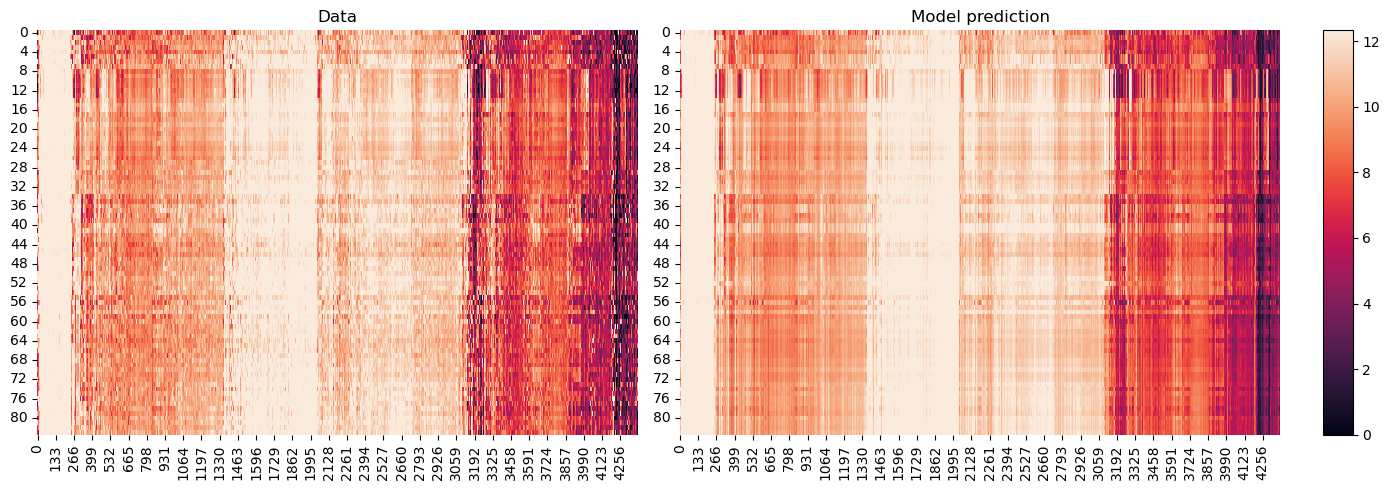

In [20]:
# Cluster rows
row_linkage = sch.linkage(x_in, method='average')
row_dendro = sch.dendrogram(row_linkage, no_plot=True)
row_order = row_dendro['leaves']

# Cluster columns
col_linkage = sch.linkage(x_in.T, method='average')
col_dendro = sch.dendrogram(col_linkage, no_plot=True)
col_order = col_dendro['leaves']

# Reorder
x_in = x_in[np.ix_(row_order, col_order)]
x_out = x_out[np.ix_(row_order, col_order)]

# Set up a gridspec layout: 1 row, 3 columns
fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05])

# Create subplots according to gridspec
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

# Common color scale
vmin = 0
vmax = np.percentile(x_in, 80)

# Plot heatmaps
sns.heatmap(x_in, ax=ax0, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)
ax0.set_title('Data')
ax0.set_yticklabels(ax0.get_yticklabels(), rotation=0)

sns.heatmap(x_out, ax=ax1, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)
ax1.set_title('Model prediction')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

# Shared colorbar
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap="rocket", norm=norm)
sm.set_array([])

fig.colorbar(sm, cax=cax, orientation='vertical')

plt.tight_layout()
plt.show()

In [21]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import matplotlib as mpl
# import seaborn as sns
# import scipy.cluster.hierarchy as sch

# # Assume: x_in, x_out = (samples, features); labels = (samples,)
# labels = trainer.test_values['y']
# x_in = x_in.reshape(-1, brca.num_nodes)
# x_out = x_out.reshape(-1, brca.num_nodes)

# # Cluster columns globally
# col_linkage = sch.linkage(x_in.T, method='average')
# col_dendro = sch.dendrogram(col_linkage, no_plot=True)
# col_order = col_dendro['leaves']

# # Apply column order
# x_in = x_in[:, col_order]
# x_out = x_out[:, col_order]

# # Cluster rows *within* each class
# unique_labels = np.unique(labels)
# row_order = []

# for cls in unique_labels:
#     cls_idx = np.where(labels == cls)[0]
#     x_cls = x_in[cls_idx]
    
#     # Cluster only this class's samples
#     row_linkage = sch.linkage(x_cls, method='average')
#     row_dendro = sch.dendrogram(row_linkage, no_plot=True)
#     cls_row_order = cls_idx[row_dendro['leaves']]  # global indices

#     row_order.extend(cls_row_order.tolist())

# # Reorder rows
# x_in = x_in[row_order]
# x_out = x_out[row_order]
# labels_ordered = labels[row_order]

# # Identify class breakpoints
# boundary_indices = np.where(np.diff(labels_ordered) != 0)[0] + 1

# # === PLOT ===

# # Set up a gridspec layout: 1 row, 3 columns
# fig = plt.figure(figsize=(14, 5))
# gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05])

# # Create subplots
# ax0 = fig.add_subplot(gs[0, 0])
# ax1 = fig.add_subplot(gs[0, 1])
# cax = fig.add_subplot(gs[0, 2])

# # Common color scale
# vmin = 0
# vmax = np.percentile(x_in, 80)

# # Plot heatmaps
# sns.heatmap(x_in, ax=ax0, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)
# ax0.set_title('Data')
# ax0.set_yticklabels([])

# sns.heatmap(x_out, ax=ax1, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)
# ax1.set_title('Model prediction')
# ax1.set_yticklabels([])

# # Draw class boundaries
# for ax in [ax0, ax1]:
#     for idx in boundary_indices:
#         ax.axhline(idx, color='black', linewidth=1)

# # Shared colorbar
# norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
# sm = mpl.cm.ScalarMappable(cmap="rocket", norm=norm)
# sm.set_array([])
# fig.colorbar(sm, cax=cax, orientation='vertical')

# plt.tight_layout()
# plt.show()


In [22]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import matplotlib as mpl
# import seaborn as sns
# import scipy.cluster.hierarchy as sch
# from matplotlib.colors import ListedColormap, BoundaryNorm
# from matplotlib.patches import Patch

# # --- Input tensors ---
# # x_in, x_out = (samples, nodes)
# # labels = (samples,)

# # --- Column clustering (global) ---
# col_linkage = sch.linkage(x_in.T, method='average')
# col_dendro = sch.dendrogram(col_linkage, no_plot=True)
# col_order = col_dendro['leaves']

# x_in = x_in[:, col_order]
# x_out = x_out[:, col_order]

# # --- Row clustering within each class ---
# labels = trainer.test_values['y']
# unique_labels = np.unique(labels)
# row_order = []

# for cls in unique_labels:
#     idx = np.where(labels == cls)[0]
#     row_linkage = sch.linkage(x_in[idx], method='average')
#     dendro = sch.dendrogram(row_linkage, no_plot=True)
#     cls_order = idx[dendro['leaves']]
#     row_order.extend(cls_order.tolist())

# x_in = x_in[row_order]
# x_out = x_out[row_order]
# labels_ordered = labels[row_order]

# # --- Class colorbar config ---
# class_colors = sns.color_palette("Set2", len(unique_labels))
# cmap = ListedColormap(class_colors)
# norm = BoundaryNorm(boundaries=np.arange(len(unique_labels)+1)-0.5, ncolors=len(unique_labels))

# # --- Class legend (optional) ---
# class_names = brca.y_labels
# unique_classes = np.unique(labels_ordered)
# print(unique_classes)

# legend_elements = [
#     Patch(facecolor=class_colors[i], label=class_names[i])
#     for i in unique_classes
# ]


# # --- Plotting ---
# fig = plt.figure(figsize=(15, 5))
# gs = gridspec.GridSpec(1, 4, width_ratios=[0.05, 1, 1, 0.05])  # left colorbar, in, out, main colorbar

# # Subplots
# ax_labels = fig.add_subplot(gs[0, 0])
# ax0 = fig.add_subplot(gs[0, 1])
# ax1 = fig.add_subplot(gs[0, 2])
# cax = fig.add_subplot(gs[0, 3])

# # Plot class strip
# ax_labels.imshow(labels_ordered.reshape(-1, 1), aspect='auto', cmap=cmap, norm=norm)
# ax_labels.set_xticks([])
# ax_labels.set_yticks([])
# ax_labels.set_title("Class", fontsize=10)

# # Heatmap scale
# vmin = 0
# vmax = np.percentile(x_in, 80)

# # Heatmaps
# sns.heatmap(x_in, ax=ax0, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)
# ax0.set_title('Data')
# ax0.set_yticklabels([])

# sns.heatmap(x_out, ax=ax1, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)
# ax1.set_title('Model prediction')
# ax1.set_yticklabels([])

# # Main colorbar
# norm_main = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
# sm = mpl.cm.ScalarMappable(cmap="rocket", norm=norm_main)
# sm.set_array([])
# fig.colorbar(sm, cax=cax, orientation='vertical')

# # Legend for class colorbar
# fig.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), title="Classes")

# plt.tight_layout()
# plt.show()


In [23]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import matplotlib as mpl
# import seaborn as sns
# import scipy.cluster.hierarchy as sch
# from matplotlib.colors import ListedColormap, BoundaryNorm
# from matplotlib.patches import Patch

# # --- Data: x_in, x_out = (samples, nodes); labels = (samples,)
# x_in = np.exp(trainer.test_values['lfc'].reshape(-1, brca.num_nodes))
# x_out = np.exp(trainer.test_values['lfc_recon'].reshape(-1, brca.num_nodes))
# labels = trainer.test_values['y']

# # --- Optional: class names (index must match label values) ---
# class_names = ['Basal', 'Her2', 'LumA', 'LumB', 'Metastatic', 'Solid Tissue Normal']
# class_colors = sns.color_palette("Set2", len(class_names))
# assert max(labels) < len(class_names), "Label index exceeds class_names list"

# # --- Global column clustering ---
# col_linkage = sch.linkage(x_in.T, method='average')
# col_order = sch.dendrogram(col_linkage, no_plot=True)['leaves']
# x_in = x_in[:, col_order]
# x_out = x_out[:, col_order]

# # --- Row clustering within each class ---
# unique_classes = np.unique(labels)
# row_order = []

# for cls in unique_classes:
#     cls_indices = np.where(labels == cls)[0]
#     cls_x = x_in[cls_indices]
#     row_linkage = sch.linkage(cls_x, method='average')
#     cls_order = cls_indices[sch.dendrogram(row_linkage, no_plot=True)['leaves']]
#     row_order.extend(cls_order.tolist())

# # Apply row reordering
# x_in = x_in[row_order]
# x_out = x_out[row_order]
# labels_ordered = labels[row_order]

# # --- Class colorbar settings ---
# cmap = ListedColormap(class_colors)
# norm = BoundaryNorm(boundaries=np.arange(len(class_names)+1)-0.5, ncolors=len(class_names))

# # --- Build legend handles only for present classes ---
# legend_elements = [
#     Patch(facecolor=class_colors[i], label=class_names[i])
#     for i in np.unique(labels_ordered)
# ]

# # --- Plotting ---
# fig = plt.figure(figsize=(15, 5))
# gs = gridspec.GridSpec(1, 4, width_ratios=[0.05, 1, 1, 0.05])

# ax_class = fig.add_subplot(gs[0, 0])
# ax0 = fig.add_subplot(gs[0, 1])
# ax1 = fig.add_subplot(gs[0, 2])
# cax = fig.add_subplot(gs[0, 3])

# # Plot class label strip
# ax_class.imshow(labels_ordered.reshape(-1, 1), aspect='auto', cmap=cmap, norm=norm)
# ax_class.set_xticks([])
# ax_class.set_yticks([])
# ax_class.set_title("Class", fontsize=10)

# # Common color scale
# vmin = 0
# vmax = np.percentile(x_in, 80)

# # Heatmaps
# sns.heatmap(x_in, ax=ax0, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)
# ax0.set_title('Data')
# ax0.set_yticklabels([])

# sns.heatmap(x_out, ax=ax1, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)
# ax1.set_title('Model prediction')
# ax1.set_yticklabels([])

# # Shared heatmap colorbar
# sm = mpl.cm.ScalarMappable(cmap="rocket", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
# sm.set_array([])
# fig.colorbar(sm, cax=cax, orientation='vertical')

# # Legend for class strip
# fig.legend(
#     handles=legend_elements,
#     loc='upper left',
#     bbox_to_anchor=(1.02, 1),
#     title="Classes"
# )

# plt.tight_layout()
# plt.show()


In [24]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import matplotlib as mpl
# import seaborn as sns
# import scipy.cluster.hierarchy as sch

# # --- Data: x_in, x_out = (samples, nodes); labels = (samples,)
# x_in = trainer.test_values['x'].reshape(-1, brca.num_nodes)
# x_out = trainer.test_values['x_recon'].reshape(-1, brca.num_nodes)
# labels = trainer.test_values['y']

# # --- Class names (index = class label) ---
# class_names = ['Basal', 'Her2', 'LumA', 'LumB', 'Metastatic', 'Solid Tissue Normal']
# assert max(labels) < len(class_names), "Label index exceeds class_names"

# # --- Global column clustering ---
# col_linkage = sch.linkage(x_in.T, method='average')
# col_order = sch.dendrogram(col_linkage, no_plot=True)['leaves']
# x_in = x_in[:, col_order]
# x_out = x_out[:, col_order]

# # --- Row clustering within each class ---
# unique_classes = np.unique(labels)
# row_order = []
# class_boundaries = []
# class_labels_for_ticks = []

# start_idx = 0
# for cls in unique_classes:
#     cls_indices = np.where(labels == cls)[0]
#     cls_x = x_in[cls_indices]
#     row_linkage = sch.linkage(cls_x, method='average')
#     cls_order = cls_indices[sch.dendrogram(row_linkage, no_plot=True)['leaves']]
#     row_order.extend(cls_order.tolist())

#     # Record boundary and label position
#     end_idx = start_idx + len(cls_order)
#     class_boundaries.append(end_idx)
#     class_labels_for_ticks.append((start_idx + end_idx) // 2)
#     start_idx = end_idx

# # Apply row reordering
# x_in = x_in[row_order]
# x_out = x_out[row_order]
# labels_ordered = labels[row_order]

# # --- Plotting ---
# fig = plt.figure(figsize=(14, 5))
# gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05])

# ax0 = fig.add_subplot(gs[0, 0])
# ax1 = fig.add_subplot(gs[0, 1])
# cax = fig.add_subplot(gs[0, 2])

# # Common color scale
# vmin = 0
# vmax = np.percentile(x_in, 80)

# # Plot heatmaps
# sns.heatmap(x_in, ax=ax0, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)
# ax0.set_title('Data')
# ax0.set_yticklabels([])

# sns.heatmap(x_out, ax=ax1, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)
# ax1.set_title('Model prediction')
# ax1.set_yticklabels([])

# # Add horizontal lines between class blocks
# for ax in [ax0, ax1]:
#     for idx in class_boundaries[:-1]:  # skip last
#         ax.axhline(idx, color='white', linewidth=2)

# # Add class labels on y-axis (centered)
# ax0.set_yticks(class_labels_for_ticks)
# ax0.set_yticklabels([class_names[i] for i in unique_classes], rotation=0)

# # Shared colorbar
# norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
# sm = mpl.cm.ScalarMappable(cmap="rocket", norm=norm)
# sm.set_array([])
# fig.colorbar(sm, cax=cax, orientation='vertical')

# plt.tight_layout()
# plt.show()


In [25]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import matplotlib as mpl
# import seaborn as sns
# import scipy.cluster.hierarchy as sch
# from matplotlib.patches import Rectangle

# # --- Data: x_in, x_out = (samples, nodes); labels = (samples,)
# x_in = np.exp(trainer.test_values['lfc'].reshape(-1, brca.num_nodes))
# x_out = np.exp(trainer.test_values['lfc_recon'].reshape(-1, brca.num_nodes))
# labels = trainer.test_values['y']

# # --- Class names (index = label value) ---
# class_names = ['Basal', 'Her2', 'LumA', 'LumB', 'Metastatic', 'Solid Tissue Normal']
# assert max(labels) < len(class_names), "Label index exceeds class_names"

# # --- Column clustering ---
# col_order = sch.dendrogram(sch.linkage(x_in.T, method='average'), no_plot=True)['leaves']
# x_in = x_in[:, col_order]
# x_out = x_out[:, col_order]

# # --- Row clustering within each class ---
# unique_classes = np.unique(labels)
# row_order = []
# x_in_blocks = []
# x_out_blocks = []
# block_sizes = []

# for cls in unique_classes:
#     idx = np.where(labels == cls)[0]
#     cls_x = x_in[idx]
#     row_linkage = sch.linkage(cls_x, method='average')
#     cls_order = idx[sch.dendrogram(row_linkage, no_plot=True)['leaves']]
    
#     x_in_blocks.append(x_in[cls_order])
#     x_out_blocks.append(x_out[cls_order])
#     block_sizes.append(len(cls_order))

#     row_order.extend(cls_order.tolist())

# # Insert NaN rows as dividers
# white_row = np.full((1, x_in.shape[1]), np.nan)
# x_in_padded = []
# x_out_padded = []
# label_ticks = []
# curr_idx = 0

# for i, (xin, xout, size) in enumerate(zip(x_in_blocks, x_out_blocks, block_sizes)):
#     x_in_padded.append(xin)
#     x_out_padded.append(xout)

#     # Save label tick position
#     label_ticks.append(curr_idx + size // 2)
#     curr_idx += size

#     # Add white space after each block except the last
#     if i < len(x_in_blocks) - 1:
#         x_in_padded.append(white_row)
#         x_out_padded.append(white_row)
#         curr_idx += 1  # spacer row

# # Stack into final arrays
# x_in_final = np.vstack(x_in_padded)
# x_out_final = np.vstack(x_out_padded)

# # --- Plotting ---
# fig = plt.figure(figsize=(14, 5))
# gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05])
# ax0 = fig.add_subplot(gs[0, 0])
# ax1 = fig.add_subplot(gs[0, 1])
# cax = fig.add_subplot(gs[0, 2])

# vmin = 0
# vmax = np.percentile(np.nan_to_num(x_in_final), 90)

# sns.heatmap(x_in_final, ax=ax0, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False, mask=np.isnan(x_in_final))
# ax0.set_title('Data')
# ax0.set_yticklabels([])

# sns.heatmap(x_out_final, ax=ax1, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False, mask=np.isnan(x_out_final))
# ax1.set_title('Model prediction')
# ax1.set_yticklabels([])

# # Add black rectangle outlines for each class block
# y = 0
# for size in block_sizes:
#     for ax in [ax0, ax1]:
#         rect = Rectangle((0, y), x_in.shape[1], size, linewidth=1, edgecolor='black', facecolor='none')
#         ax.add_patch(rect)
#     y += size + 1  # +1 for white divider row

# # Add y-tick labels at block centers
# ax0.set_yticks(label_ticks)
# ax0.set_yticklabels([class_names[i] for i in unique_classes], rotation=0)

# # Shared colorbar
# sm = mpl.cm.ScalarMappable(cmap="rocket", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
# sm.set_array([])
# fig.colorbar(sm, cax=cax, orientation='vertical')

# plt.tight_layout()
# plt.show()


In [26]:
brca.y_labels

['Basal', 'Her2', 'LumA', 'LumB', 'Metastatic', 'Solid Tissue Normal']

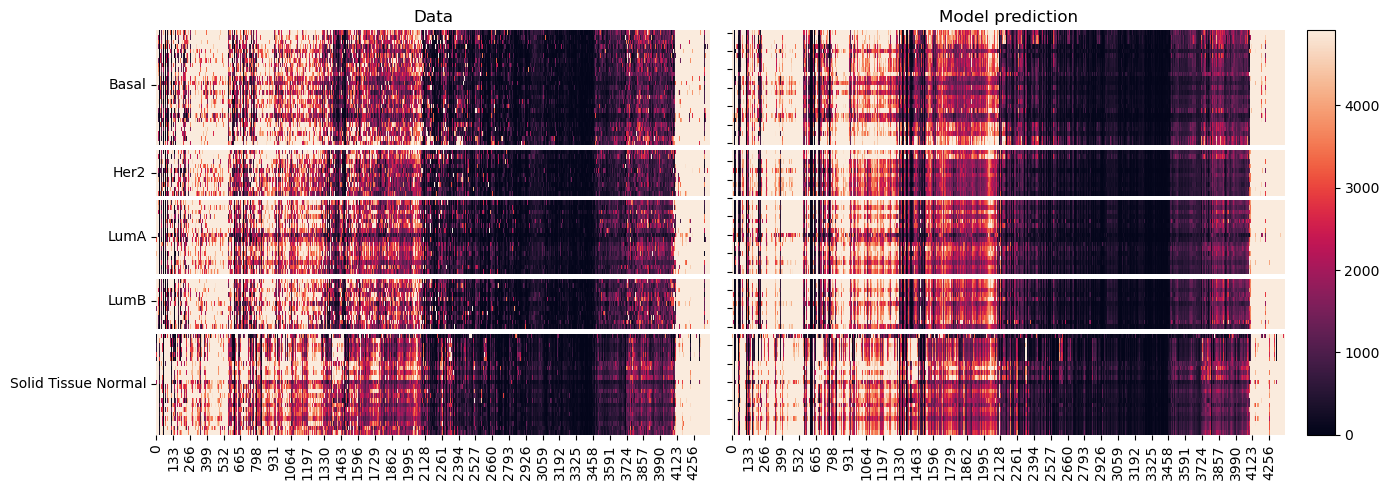

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import seaborn as sns
import scipy.cluster.hierarchy as sch
from matplotlib.patches import Rectangle

# --- Input data ---
x_in = trainer.test_values['x'].reshape(-1, brca.num_nodes)
x_out = trainer.test_values['x_recon'].reshape(-1, brca.num_nodes)
labels = trainer.test_values['y']

# --- Class metadata ---
class_names = brca.y_labels
assert max(labels) < len(class_names), "Label index exceeds class_names"

# --- Column clustering ---
col_order = sch.dendrogram(sch.linkage(x_in.T, method='average'), no_plot=True)['leaves']
x_in = x_in[:, col_order]
x_out = x_out[:, col_order]

# --- Cluster rows within each class ---
unique_classes = np.unique(labels)
row_order = []
x_in_blocks, x_out_blocks = [], []
block_sizes = []

# for cls in unique_classes:
#     cls_indices = np.where(labels == cls)[0]
#     cls_x = x_in[cls_indices]
#     row_linkage = sch.linkage(cls_x, method='average')
#     cls_order = cls_indices[sch.dendrogram(row_linkage, no_plot=True)['leaves']]

for cls in np.unique(labels):
    cls_indices = np.where(labels == cls)[0]
    cls_x = x_in[cls_indices]

    if cls_x.shape[0] < 2:
        cls_order = cls_indices  # no sorting possible, just use original order
    else:
        row_linkage = sch.linkage(cls_x, method='average')
        cls_order = cls_indices[sch.dendrogram(row_linkage, no_plot=True)['leaves']]
        
    x_in_blocks.append(x_in[cls_order])
    x_out_blocks.append(x_out[cls_order])
    block_sizes.append(len(cls_order))

    row_order.extend(cls_order.tolist())

# --- Add white space between class blocks ---
num_white_rows = 1  # ADJUST SPACING HERE
white_row = np.full((num_white_rows, x_in.shape[1]), np.nan)

x_in_padded, x_out_padded = [], []
label_ticks = []
curr_idx = 0

for i, (xin_block, xout_block, size) in enumerate(zip(x_in_blocks, x_out_blocks, block_sizes)):
    x_in_padded.append(xin_block)
    x_out_padded.append(xout_block)
    
    # Save tick position (center of block)
    label_ticks.append(curr_idx + size // 2)
    curr_idx += size

    if i < len(x_in_blocks) - 1:
        x_in_padded.append(white_row)
        x_out_padded.append(white_row)
        curr_idx += num_white_rows

# --- Stack padded arrays ---
x_in_final = np.vstack(x_in_padded)
x_out_final = np.vstack(x_out_padded)

# --- Plotting ---
fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05])
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

vmin = 0
vmax = np.percentile(np.nan_to_num(x_in_final), 80)

# Heatmaps with white (NaN) gaps
sns.heatmap(x_in_final, ax=ax0, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False, mask=np.isnan(x_in_final))
ax0.set_title('Data')
ax0.set_yticklabels([])

sns.heatmap(x_out_final, ax=ax1, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False, mask=np.isnan(x_out_final))
ax1.set_title('Model prediction')
ax1.set_yticklabels([])

# # Add black rectangles around each class block
# y = 0
# for size in block_sizes:
#     for ax in [ax0, ax1]:
#         rect = Rectangle((0, y), x_in.shape[1], size, linewidth=1, edgecolor='black', facecolor='none')
#         ax.add_patch(rect)
#     y += size + num_white_rows

# Add class names to y-axis (centered in each block)
ax0.set_yticks(label_ticks)
ax0.set_yticklabels([class_names[i] for i in unique_classes], rotation=0)

# Shared colorbar
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap="rocket", norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, orientation='vertical')

plt.tight_layout()
plt.show()


In [28]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import matplotlib as mpl
# import seaborn as sns
# import scipy.cluster.hierarchy as sch

# # --- Input data ---
# x_in = trainer.test_values['x'].reshape(-1, brca.num_nodes)
# x_out = trainer.test_values['x_recon'].reshape(-1, brca.num_nodes)
# labels = trainer.test_values['y']

# # --- Class metadata ---
# class_names = ['Basal', 'Her2', 'LumA', 'LumB', 'Metastatic', 'Solid Tissue Normal']
# assert max(labels) < len(class_names), "Label index exceeds class_names"

# # --- Global column clustering ---
# col_order = sch.dendrogram(sch.linkage(x_in.T, method='average'), no_plot=True)['leaves']
# x_in = x_in[:, col_order]
# x_out = x_out[:, col_order]

# # --- Per-class clustering and block extraction ---
# unique_classes = np.unique(labels)
# x_in_blocks = []
# x_out_blocks = []
# block_titles = []
# block_sizes = []

# for cls in unique_classes:
#     idx = np.where(labels == cls)[0]
#     x_in_cls = x_in[idx]
#     x_out_cls = x_out[idx]

#     # Row clustering within class
#     row_linkage = sch.linkage(x_in_cls, method='average')
#     order = sch.dendrogram(row_linkage, no_plot=True)['leaves']

#     x_in_blocks.append(x_in_cls[order])
#     x_out_blocks.append(x_out_cls[order])
#     block_titles.append(class_names[cls])
#     block_sizes.append(len(order))

# # --- Shared color scale ---
# vmin = 0
# vmax = np.percentile(np.vstack(x_in_blocks), 80)

# # --- Set up gridspec with height_ratios proportional to block size ---
# n_classes = len(x_in_blocks)
# fig_height_per_row = 0.05  # adjust this for vertical spacing
# total_height = fig_height_per_row * sum(block_sizes)
# fig = plt.figure(figsize=(12, total_height))
# gs = gridspec.GridSpec(
#     n_classes, 3,
#     width_ratios=[1, 1, 0.05],
#     height_ratios=block_sizes,
#     wspace=0.05,
#     hspace=0.3
# )

# # --- Plot each class block ---
# for i, (xin, xout, name) in enumerate(zip(x_in_blocks, x_out_blocks, block_titles)):
#     ax_in = fig.add_subplot(gs[i, 0])
#     ax_out = fig.add_subplot(gs[i, 1])

#     sns.heatmap(xin, ax=ax_in, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)
#     sns.heatmap(xout, ax=ax_out, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)

#     # Add black borders
#     n_rows, n_cols = xin.shape
#     for ax in [ax_in, ax_out]:
#         rect = Rectangle(
#             (-0.5, -0.5), n_cols, n_rows,
#             linewidth=2, edgecolor='black', facecolor='none'
#         )
#         ax.add_patch(rect)

#     ax_in.set_ylabel(name, rotation=0, ha='right', va='center', fontsize=10)
#     ax_in.set_yticks([])
#     ax_out.set_yticks([])
#     ax_in.set_xticks([])
#     ax_out.set_xticks([])

#     if i == 0:
#         ax_in.set_title("Data")
#         ax_out.set_title("Model prediction")


# # --- Shared colorbar
# sm = mpl.cm.ScalarMappable(cmap="rocket", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
# sm.set_array([])
# cbar_ax = fig.add_subplot(gs[:, 2])
# fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label='Expression')

# plt.tight_layout()
# plt.show()


In [29]:
brca.y_labels

['Basal', 'Her2', 'LumA', 'LumB', 'Metastatic', 'Solid Tissue Normal']

<Axes: >

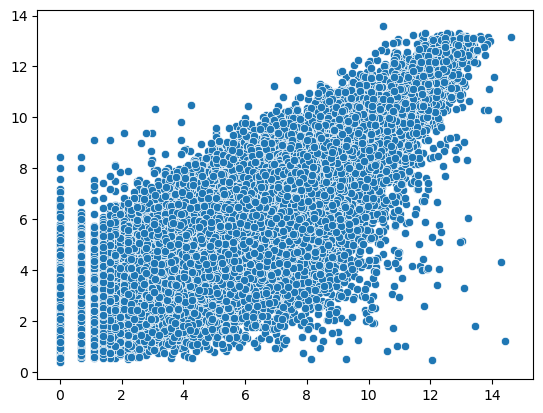

In [30]:
n = 5
sns.scatterplot(x=np.log(trainer.test_values['x']+1).reshape(-1), y=np.log(trainer.test_values['x_recon']+1).reshape(-1))

<Axes: >

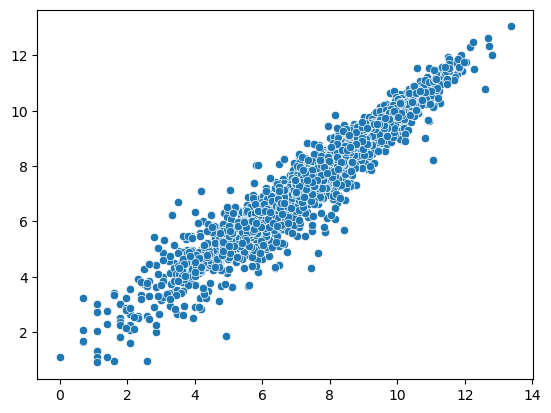

In [31]:
n = 10
sns.scatterplot(x=np.log(trainer.test_values['x']+1).reshape(-1,brca.num_nodes)[n], y=np.log(trainer.test_values['x_recon']+1).reshape(-1,brca.num_nodes)[n])

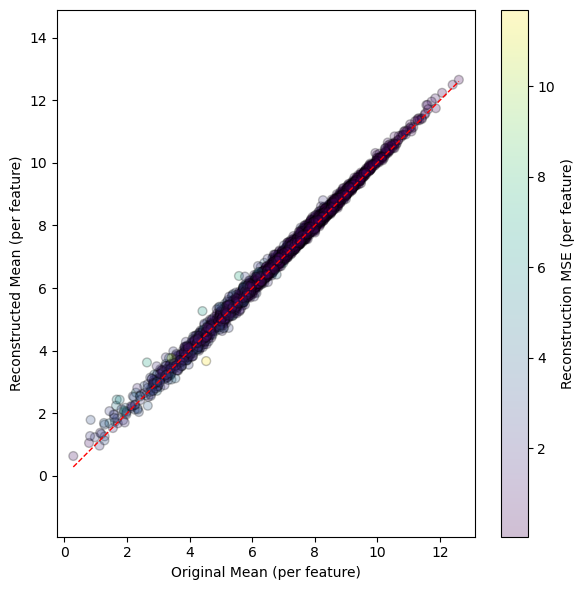

In [40]:
import torch
import matplotlib.pyplot as plt

# Assume x and x_recon are (samples, features) tensors
x = np.log(trainer.test_values['x']+1).reshape(-1,brca.num_nodes)
x_recon = np.log(trainer.test_values['x_recon']+1).reshape(-1,brca.num_nodes)

# Compute per-feature statistics
x_mean = x.mean(axis=0)               # (features,)
x_recon_mean = x_recon.mean(axis=0)   # (features,)
recon_mse = ((x - x_recon) ** 2).mean(axis=0)  # MSE per feature

# Scatterplot: one point per feature, colored by reconstruction MSE
plt.figure(figsize=(6, 6))
sc = plt.scatter(x_mean, x_recon_mean, c=recon_mse, cmap='viridis', s=40, edgecolor='k', alpha=0.25)
plt.plot([x_mean.min(), x_mean.max()], [x_mean.min(), x_mean.max()], 'r--', linewidth=1)

# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label("Reconstruction MSE (per feature)")

# Labels and formatting
plt.xlabel("Original Mean (per feature)")
plt.ylabel("Reconstructed Mean (per feature)")
# plt.title("Feature-wise Reconstruction with MSE Color Encoding")
# plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()


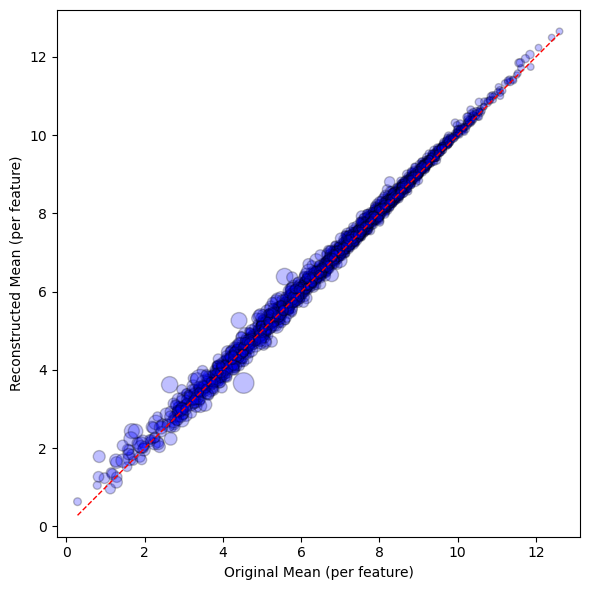

In [58]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Assume x and x_recon are (samples, features) tensors
x = np.log(trainer.test_values['x'] + 1).reshape(-1, brca.num_nodes)
x_recon = np.log(trainer.test_values['x_recon'] + 1).reshape(-1, brca.num_nodes)

# Compute per-feature statistics
x_mean = x.mean(axis=0)               # (features,)
x_recon_mean = x_recon.mean(axis=0)   # (features,)
recon_mse = ((x - x_recon) ** 2).mean(axis=0)  # MSE per feature

# Normalize MSE for visualization as point size
mse_size = 20 + 200 * (recon_mse - recon_mse.min()) / (recon_mse.ptp() + 1e-8)

# Scatterplot: size by MSE, color uniform
plt.figure(figsize=(6, 6))
sc = plt.scatter(x_mean, x_recon_mean, s=mse_size, color='blue', edgecolor='k', alpha=0.25)

# Reference diagonal
plt.plot([x_mean.min(), x_mean.max()], [x_mean.min(), x_mean.max()], 'r--', linewidth=1)

# Labels and formatting
plt.xlabel("Original Mean (per feature)")
plt.ylabel("Reconstructed Mean (per feature)")
plt.axis("equal")
plt.tight_layout()
plt.show()


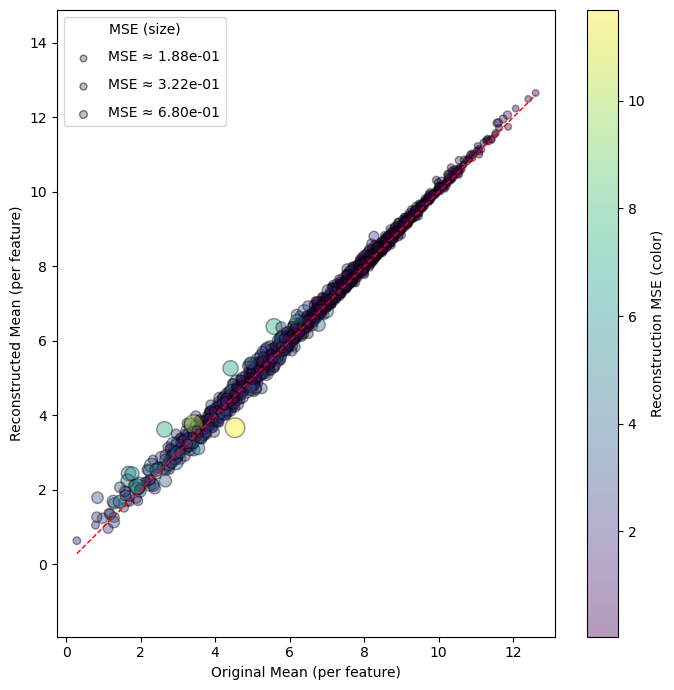

In [71]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Assume x and x_recon are (samples, features) numpy arrays
x = np.log(trainer.test_values['x'] + 1).reshape(-1, brca.num_nodes)
x_recon = np.log(trainer.test_values['x_recon'] + 1).reshape(-1, brca.num_nodes)

# Compute per-feature stats
x_mean = x.mean(axis=0)
x_recon_mean = x_recon.mean(axis=0)
recon_mse = ((x - x_recon) ** 2).mean(axis=0)

# Normalize MSE for point size
size_min, size_max = 20, 200
mse_size = size_min + (size_max - size_min) * (recon_mse - recon_mse.min()) / (recon_mse.ptp() + 1e-8)

# Scatterplot with both color and size
plt.figure(figsize=(7, 7))
sc = plt.scatter(x_mean, x_recon_mean, s=mse_size, c=recon_mse, cmap='viridis', edgecolor='k', alpha=0.40)

# Reference line
plt.plot([x_mean.min(), x_mean.max()], [x_mean.min(), x_mean.max()], 'r--', linewidth=1)

# Colorbar for MSE
cbar = plt.colorbar(sc)
cbar.set_label("Reconstruction MSE (color)")

# Size legend (manually created)
for val in [np.percentile(recon_mse, p) for p in [25, 50, 75]]:
    plt.scatter([], [], s=size_min + (size_max - size_min) * (val - recon_mse.min()) / recon_mse.ptp(),
                c='gray', alpha=0.5, edgecolors='k', label=f"MSE ≈ {val:.2e}")
plt.legend(scatterpoints=1, frameon=True, labelspacing=1, title="MSE (size)")

# Labels
plt.xlabel("Original Mean (per feature)")
plt.ylabel("Reconstructed Mean (per feature)")
plt.axis("equal")
plt.tight_layout()
plt.show()


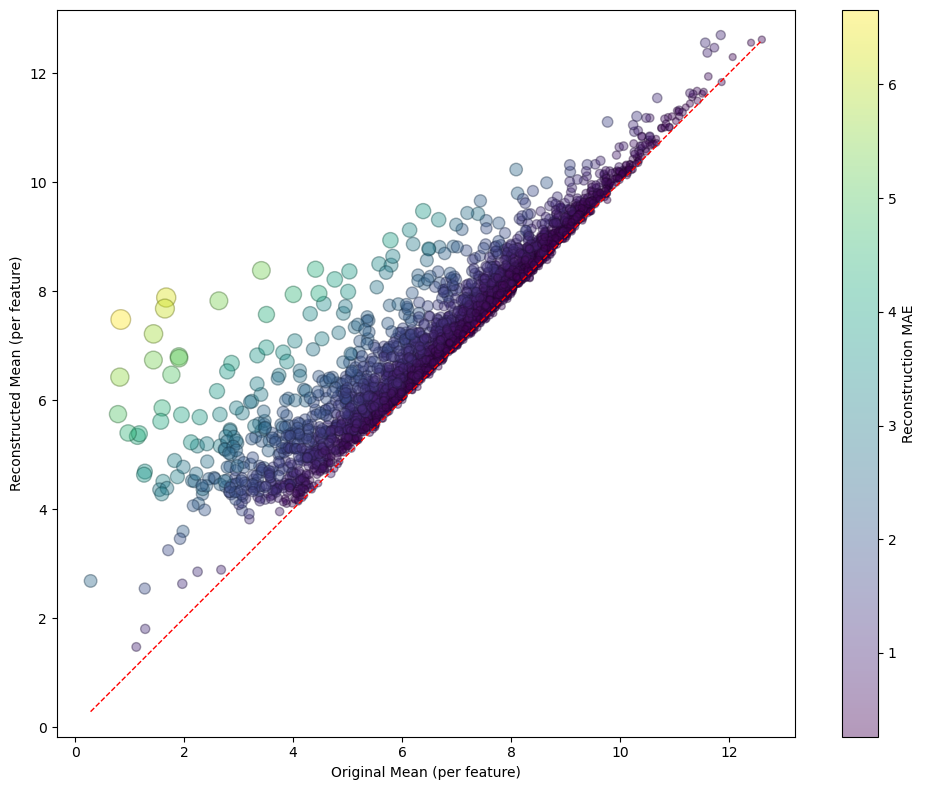

In [95]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Assume x and x_recon are (samples, features) numpy arrays
x = np.log(trainer.test_values['x'] + 1).reshape(-1, brca.num_nodes)
x_recon = np.log(trainer.test_values['mu'] + 1).reshape(-1, brca.num_nodes)

# Compute per-feature stats
x_mean = x.mean(axis=0)
x_recon_mean = x_recon.mean(axis=0)

# Choose your metric: 'mae' or 'rmse'
error_type = 'mae'  # or 'mae'

if error_type == 'mae':
    recon_error = np.array([mean_absolute_error(x[:, i], x_recon[:, i]) for i in range(x.shape[1])])
    error_label = "Reconstruction MAE"
elif error_type == 'rmse':
    recon_error = np.array([root_mean_squared_error(x[:, i], x_recon[:, i]) for i in range(x.shape[1])])
    error_label = "Reconstruction RMSE"
else:
    raise ValueError("error_type must be 'mae' or 'rmse'")

# Normalize error for point size
size_min, size_max = 20, 200
mse_size = size_min + (size_max - size_min) * (recon_error - recon_error.min()) / (recon_error.ptp() + 1e-8)

# Normalize error values for colormap
norm = mcolors.Normalize(vmin=recon_error.min(), vmax=recon_error.max())
cmap = plt.colormaps['viridis']  # updated way
colors = cmap(norm(recon_error))  # RGBA array (features, 4)

# Create darker edge colors by scaling RGB, preserve alpha
dark_edge_colors = colors.copy()
dark_edge_colors[:, :3] *= 0.5  # Darken RGB
dark_edge_colors[:, 3] = 1    # Set edge alpha

# Scatterplot with both color and size
plt.figure(figsize=(10, 8))
sc = plt.scatter(x_mean, x_recon_mean, c=recon_error, cmap='viridis', edgecolor=dark_edge_colors, alpha=0.4, s=mse_size)

# Reference line
plt.plot([x_mean.min(), x_mean.max()], [x_mean.min(), x_mean.max()], 'r--', linewidth=1)

# Colorbar for MAE/RMSE
cbar = plt.colorbar(sc)
cbar.set_label(f"{error_label}")

# Labels
plt.xlabel("Original Mean (per feature)")
plt.ylabel("Reconstructed Mean (per feature)")
plt.axis("equal")
plt.tight_layout()
plt.show()


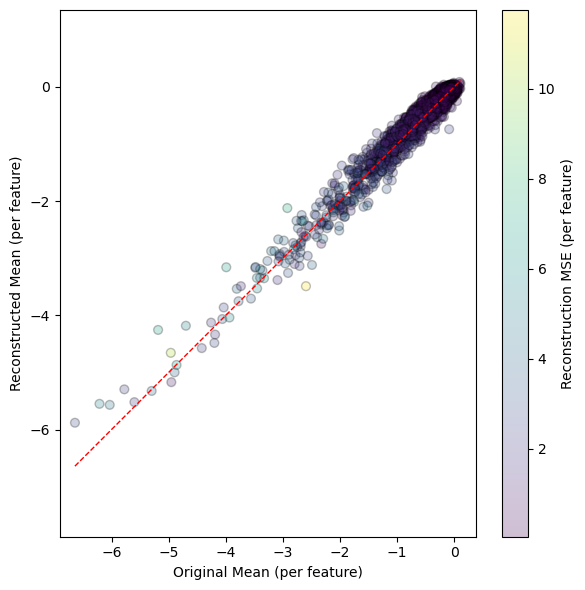

In [41]:
import torch
import matplotlib.pyplot as plt

# Assume x and x_recon are (samples, features) tensors
x = trainer.test_values['lfc'].reshape(-1,brca.num_nodes)
x_recon = trainer.test_values['lfc_recon'].reshape(-1,brca.num_nodes)

# Compute per-feature statistics
x_mean = x.mean(axis=0)               # (features,)
x_recon_mean = x_recon.mean(axis=0)   # (features,)
recon_mse = ((x - x_recon) ** 2).mean(axis=0)  # MSE per feature

# Scatterplot: one point per feature, colored by reconstruction MSE
plt.figure(figsize=(6, 6))
sc = plt.scatter(x_mean, x_recon_mean, c=recon_mse, cmap='viridis', s=40, edgecolor='k', alpha=0.25)
plt.plot([x_mean.min(), x_mean.max()], [x_mean.min(), x_mean.max()], 'r--', linewidth=1)

# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label("Reconstruction MSE (per feature)")

# Labels and formatting
plt.xlabel("Original Mean (per feature)")
plt.ylabel("Reconstructed Mean (per feature)")
# plt.title("Feature-wise Reconstruction with MSE Color Encoding")
# plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()


In [34]:
trainer.test_values['lfc'].reshape(-1,brca.num_nodes)[0]

array([ 0.43023252, -0.28817368, -0.02678633, ...,  0.05090237,
        0.12957   ,  0.34248114], dtype=float32)

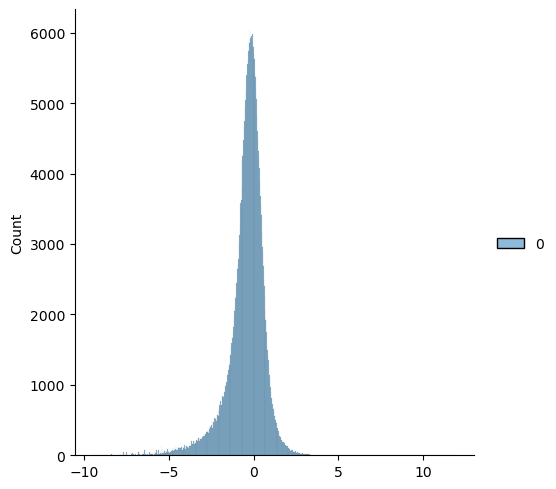

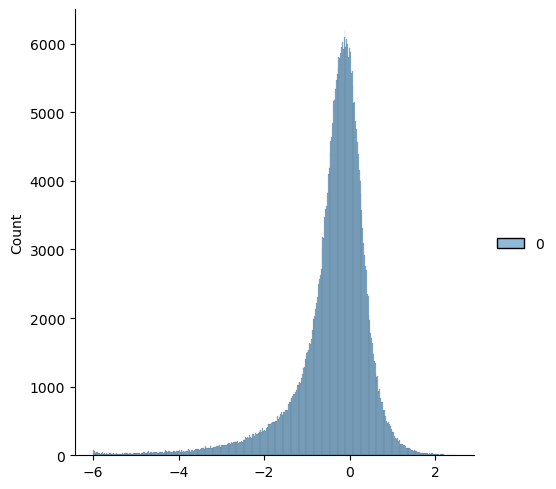

In [35]:
sns.displot(trainer.test_values['lfc'])
sns.displot(trainer.test_values['lfc_recon'])

In [36]:
x_in.shape

(84, 4383)

In [37]:
trainer.test_values

{'y': array([2, 0, 0, 2, 0, 0, 3, 3, 5, 0, 5, 1, 0, 0, 0, 1, 0, 2, 5, 0, 0, 2,
        5, 5, 0, 1, 5, 0, 5, 3, 3, 1, 2, 2, 1, 1, 5, 5, 0, 5, 2, 5, 0, 3,
        5, 0, 1, 0, 1, 0, 1, 5, 5, 5, 0, 2, 3, 0, 1, 3, 3, 2, 5, 2, 0, 0,
        2, 0, 2, 0, 2, 5, 5, 2, 3, 5, 5, 3, 3, 0, 2, 5, 5, 2]),
 'x': array([[ 3470.],
        [ 3140.],
        [ 1750.],
        ...,
        [ 3605.],
        [10411.],
        [  552.]], dtype=float32),
 'x_recon': array([[2535.462  ],
        [2568.0488 ],
        [1381.0653 ],
        ...,
        [3197.2996 ],
        [7131.7476 ],
        [ 798.88794]], dtype=float32),
 'mu': array([[ 2257.3918],
        [ 4190.06  ],
        [ 1798.5365],
        ...,
        [ 3870.8616],
        [10583.846 ],
        [ 1358.9524]], dtype=float32),
 'theta': array([[1.2181268],
        [1.1887978],
        [1.1990267],
        ...,
        [1.217904 ],
        [1.217062 ],
        [1.2159995]], dtype=float32),
 'lfc': array([[ 0.43023252],
        [-0.28817368],
       

In [38]:
y = trainer.test_values['y']
x = trainer.test_values['x']

In [108]:
Batch.from_data_list(_dataset)

DataBatch(x=[2463246, 1], edge_index=[2, 18432476], edge_attr=[18432476, 16], y=[562], sample_id=[562], pe=[2463246, 16], batch=[2463246], ptr=[563])

In [109]:
trainer.model(Batch.from_data_list(_dataset))

{'x_recon': tensor([[ 1549.1810],
         [ 2202.7429],
         [ 2120.7146],
         ...,
         [ 4888.8481],
         [14820.0127],
         [ 1581.1403]], device='cuda:4', grad_fn=<MulBackward0>),
 'lfc_recon': tensor([[-0.3765],
         [-0.6430],
         [ 0.1648],
         ...,
         [ 0.2335],
         [ 0.3366],
         [ 0.1514]], device='cuda:4', grad_fn=<ViewBackward0>),
 'lfc': tensor([[ 0.0148],
         [-1.1319],
         [ 0.0459],
         ...,
         [-0.2169],
         [-0.3664],
         [ 0.0132]], device='cuda:4', grad_fn=<SubBackward0>),
 'mu': tensor([[ 2257.3918],
         [ 4190.0601],
         [ 1798.5365],
         ...,
         [ 3870.8616],
         [10583.8457],
         [ 1358.9524]], device='cuda:4', grad_fn=<ExpBackward0>),
 'theta': tensor([[1.2181],
         [1.1888],
         [1.1990],
         ...,
         [1.2179],
         [1.2171],
         [1.2160]], device='cuda:4', grad_fn=<ExpBackward0>)}